In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity

from sentence_transformers import SentenceTransformer

from tqdm import tqdm

from collections import Counter

In [ ]:
!pip install -q sentence-transformers

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

DATA_PATH="/content/drive/MyDrive/FIFI_Research/data"

train_df=pd.read_csv(os.path.join(DATA_PATH,"train.tsv"),sep="\t")

In [ ]:
def jaccard_similarity(a, b):

    set1 = set(a.lower().split())

    set2 = set(b.lower().split())

    intersection = len(set1 & set2)

    union = len(set1 | set2)

    if union == 0:
        return 0

    return intersection / union

In [ ]:
tqdm.pandas()

train_df["jaccard"] = train_df.progress_apply(
    lambda x: jaccard_similarity(
        x["generated_title"],
        x["original_title"]
    ),
    axis=1
)

100%|██████████| 90000/90000 [00:01<00:00, 55649.70it/s]


In [ ]:
train_df["jaccard"].describe()

,jaccard
count,90000.000000
mean,0.174734
std,0.142143
min,0.000000
25%,0.062500
50%,0.142857
75%,0.250000
max,1.000000


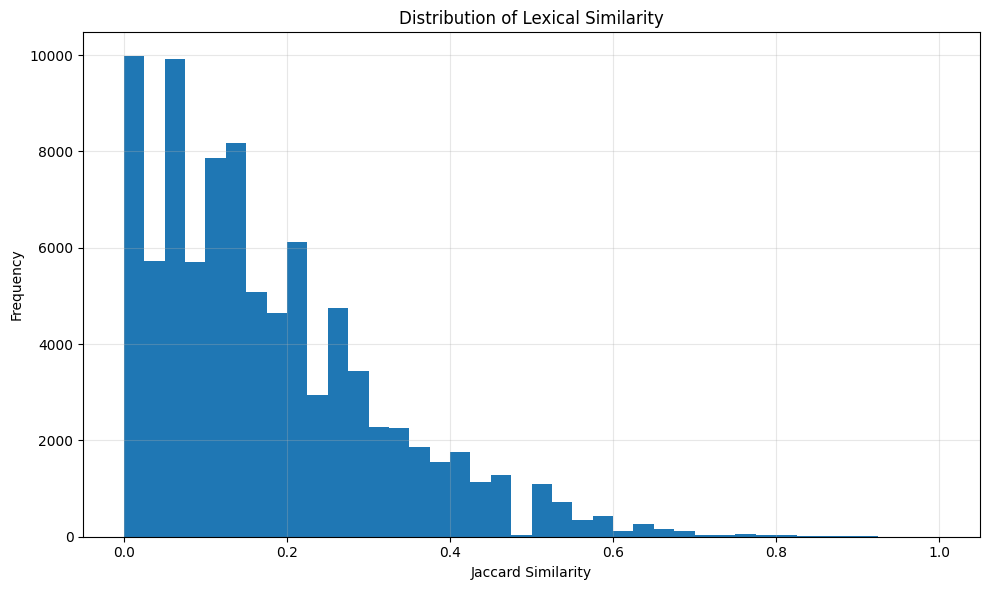

In [ ]:
plt.figure(figsize=(10,6))

plt.hist(train_df["jaccard"],
         bins=40)

plt.xlabel("Jaccard Similarity")

plt.ylabel("Frequency")

plt.title("Distribution of Lexical Similarity")

plt.grid(alpha=.3)

plt.tight_layout()

plt.savefig(
"/content/drive/MyDrive/FIFI_Research/figures/Figure8_Jaccard.png",
dpi=300)

plt.show()

In [ ]:
train_df.groupby("category")["jaccard"].describe()

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
accessible,30000.0,0.112134,0.097245,0.0,0.045455,0.095238,0.166667,0.727273
catchy,30000.0,0.126138,0.099128,0.0,0.052632,0.111111,0.181818,0.700000
technical,30000.0,0.285931,0.150620,0.0,0.176471,0.266667,0.380952,1.000000


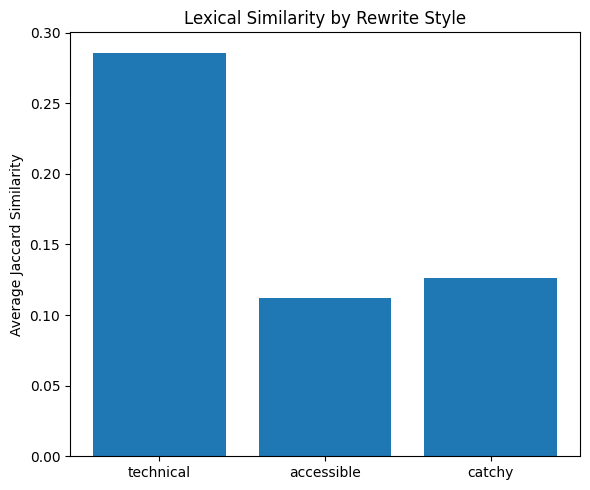

In [ ]:
categories=["technical","accessible","catchy"]

scores=[]

for c in categories:

    scores.append(
        train_df[
            train_df["category"]==c
        ]["jaccard"].mean()
    )

plt.figure(figsize=(6,5))

plt.bar(categories,scores)

plt.ylabel("Average Jaccard Similarity")

plt.title("Lexical Similarity by Rewrite Style")

plt.tight_layout()

plt.savefig(
"/content/drive/MyDrive/FIFI_Research/figures/Figure9_Jaccard_Category.png",
dpi=300)

plt.show()

In [ ]:
model = SentenceTransformer(
    "BAAI/bge-base-en-v1.5"
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
# Generated titles
generated_embeddings = model.encode(
    train_df["generated_title"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)

Batches:   0%|          | 0/1407 [00:00<?, ?it/s]

In [ ]:
# Original titles

original_embeddings = model.encode(
    train_df["original_title"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)

Batches:   0%|          | 0/1407 [00:00<?, ?it/s]

In [ ]:
semantic_scores = np.sum(
    generated_embeddings * original_embeddings,
    axis=1
)

train_df["semantic_similarity"] = semantic_scores

NameError: name 'original_embeddings' is not defined

In [ ]:
train_df["semantic_similarity"].describe()

In [ ]:
plt.figure(figsize=(10,6))

plt.hist(
    train_df["semantic_similarity"],
    bins=40
)

plt.xlabel("Cosine Similarity")

plt.ylabel("Frequency")

plt.title("Semantic Similarity Distribution")

plt.grid(alpha=.3)

plt.tight_layout()

plt.savefig(
"/content/drive/MyDrive/FIFI_Research/figures/Figure10_Semantic.png",
dpi=300)

plt.show()

In [ ]:
scores=[]

for c in categories:

    scores.append(
        train_df[
            train_df.category==c
        ]["semantic_similarity"].mean()
    )

plt.figure(figsize=(6,5))

plt.bar(categories,scores)

plt.ylabel("Average Semantic Similarity")

plt.title("Semantic Similarity by Rewrite Style")

plt.tight_layout()

plt.savefig(
"/content/drive/MyDrive/FIFI_Research/figures/Figure11_Semantic_Category.png",
dpi=300)

plt.show()

In [ ]:
summary = train_df.groupby("category").agg({

    "generated_words":"mean",

    "original_words":"mean",

    "jaccard":"mean",

    "semantic_similarity":"mean"

})

summary

In [ ]:
summary.to_csv(
"/content/drive/MyDrive/FIFI_Research/results/style_summary.csv"
)

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    train_df["jaccard"],
    train_df["semantic_similarity"],
    alpha=0.2,
    s=8
)

plt.xlabel("Jaccard Similarity")

plt.ylabel("Semantic Similarity")

plt.title("Lexical vs Semantic Similarity")

plt.grid(alpha=.3)

plt.tight_layout()

plt.savefig(
"/content/drive/MyDrive/FIFI_Research/figures/Figure12_Lexical_vs_Semantic.png",
dpi=300)

plt.show()